# 05: Evaluation

In [1]:
import sys
sys.path.append("../src")
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt

import preprocessing
import imu
import building
import ble
import evaluation
import particle_filter as pf
import visualization as viz

RAW = "../data/raw"
REF = "../assignment/Paths_references.xlsx"

## Methodology

## Per run results

In [2]:
rows = []
for run_id in [1, 2, 3, 4]:
    run = preprocessing.load_run(run_id, raw_dir=RAW)
    cfg = preprocessing.RUN_START[run_id]
    motion = imu.build_motion_table(run, initial_heading=cfg["initial_heading"])
    traj, _, _ = pf.run_filter(run, motion, start=cfg["start"], floor=cfg["floor"],
                               building=building, ble=ble, seed=0)
    metrics = evaluation.summary_metrics(
        evaluation.error_at_references(traj, evaluation.load_reference(run_id, reference_file=REF)))
    metrics["run"] = run_id
    rows.append(metrics)

summary = pd.DataFrame(rows)[["run", "mean_error_m", "median_error_m",
                              "max_error_m", "floor_accuracy", "n_checkpoints"]]
summary

,run,mean_error_m,median_error_m,max_error_m,floor_accuracy,n_checkpoints
0,1,14.45,4.44,50.62,0.53,15
1,2,29.27,25.96,67.23,0.47,15
2,3,17.53,18.06,43.89,0.68,22
3,4,19.76,16.83,45.72,0.70,23


## Error at reference points (Run 1)

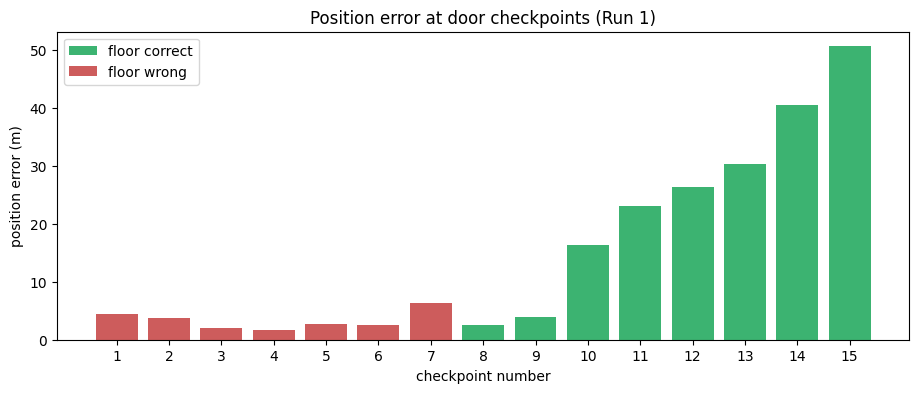

In [3]:
run = preprocessing.load_run(1, raw_dir=RAW)
cfg = preprocessing.RUN_START[1]
motion = imu.build_motion_table(run, initial_heading=cfg["initial_heading"])
traj = pf.run_filter(run, motion, start=cfg["start"], floor=cfg["floor"],
                     building=building, ble=ble, seed=0)[0]

per_checkpoint = evaluation.error_at_references(traj, evaluation.load_reference(1, reference_file=REF))
viz.plot_error_at_references(per_checkpoint, run_id=1)
plt.show()

In [4]:
def variants(run_id):
    run = preprocessing.load_run(run_id, raw_dir=RAW)
    cfg = preprocessing.RUN_START[run_id]
    motion = imu.build_motion_table(run, initial_heading=cfg["initial_heading"])
    t_map = pf.run_with_constraints(run, motion, start=cfg["start"], building=building, floor=0, seed=0)[0]
    t_ble = pf.run_with_ble(run, motion, start=cfg["start"], building=building, ble=ble, floor=0, seed=0)[0]
    t_full = pf.run_filter(run, motion, start=cfg["start"], floor=cfg["floor"], building=building, ble=ble, seed=0)[0]
    return evaluation.compare_metrics(
        {"map-only": t_map, "map+BLE": t_ble, "full": t_full},
        evaluation.load_reference(run_id, reference_file=REF))

all_runs = pd.concat([variants(r) for r in [1, 2, 3, 4]])
ablation = all_runs.groupby("variant", sort=False).mean(numeric_only=True).reset_index()
ablation[["variant", "mean_error_m", "median_error_m", "floor_accuracy"]].round(2)

,variant,mean_error_m,median_error_m,floor_accuracy
0,map-only,20.14,16.30,0.47
1,map+BLE,20.69,16.87,0.47
2,full,20.25,16.32,0.60


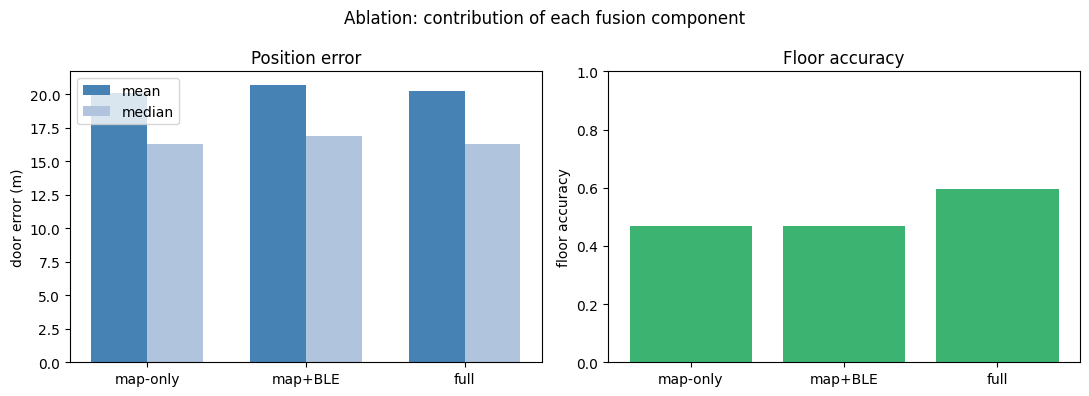

In [5]:
viz.plot_ablation(ablation)
plt.show()